In [1]:
import logging
from tqdm.notebook import tqdm
import pandas as pd
import numpy as np
import pandas as pd
import os
from notebooks.covar_examine.covariate_utils import compute_cross_correlation
from matplotlib import pyplot as plt


logging.basicConfig(level=logging.INFO)

In [2]:
%load_ext autoreload
%autoreload 2

### CSV to HF (.arrow) data converstion

In [3]:
import pandas as pd
from ts_toolkit.dataloaders.utils import convert_csv_to_hf_dataset

for dataset_name in ["covid", "nvidia_120_leak"]: # 
    if dataset_name == "covid":
        timestamp_col = 'Week start date'
        frequency = 'W'
    else:
        timestamp_col = 'Date'
        frequency = 'D'

    # df.drop(columns=[c for c in df.columns if 'Unnamed' in c], inplace=True)
    # # remove $ from all columns
    # for col in df.columns:
    #     if df[col].dtype == 'object':
    #         df[col] = df[col].str.replace('$', '').str.replace(',', '')
    # df[["Close amount", "Close amount 16-step leak"]] = df[["Close amount", "Close amount 16-step leak"]].astype(np.float32)
    df = pd.read_csv(f'data/real/{dataset_name}.csv')
    
    if True:
        convert_csv_to_hf_dataset("data/real", dataset_name, timestamp_col=timestamp_col, frequency=frequency)
    else:
        display(df)
if False:
    df = pd.read_csv(f'data/real/covid.csv')
    cross_correlation = compute_cross_correlation(df[["COVID-19 deaths", "COVID-19 hospital admissions"]].values.T)
    cross_correlation.shape
    plt.figure(figsize=(3, 3))
    plt.plot(cross_correlation[0, 1, :])


INFO:datasets:JAX version 0.7.1 available.


Loading CSV dataset from: data/real


,V_0,V_1
2020-04-05,253,331
2020-04-12,369,406
2020-04-19,467,468
2020-04-26,429,473
2020-05-03,326,403
...,...,...
2021-11-28,39,211
2021-12-05,51,231
2021-12-12,45,294
2021-12-19,53,469


Dataset sample: 2020-04-05 00:00:00, 2021-12-26 00:00:00, length: 91, freq: W, item_id: covid_sample_000000


Saving the dataset (0/1 shards):   0%|          | 0/1 [00:00<?, ? examples/s]

Loading CSV dataset from: data/real


,V_0,V_1
2024-01-02,48.17,126.09
2024-01-03,47.57,126.40
2024-01-04,48.00,123.99
2024-01-05,49.10,123.54
2024-01-06,49.10,123.54
...,...,...
2025-07-07,158.24,188.61
2025-07-08,160.00,190.53
2025-07-09,162.88,188.22
2025-07-10,164.10,187.54


Dataset sample: 2024-01-02 00:00:00, 2025-07-11 00:00:00, length: 557, freq: D, item_id: nvidia_120_leak_sample_000000


Saving the dataset (0/1 shards):   0%|          | 0/1 [00:00<?, ? examples/s]

/home/nafiseh/GitHub/timeseries-research/.venv/lib/python3.11/site-packages/fs/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)  # type: ignore
INFO:ts_toolkit.pipeline.runner:   - Results will be saved to: /home/nafiseh/GitHub/timeseries-research/tmp_results/Chronos2-Real_20260212-143058/Chronos2-Real
INFO:ts_toolkit.pipeline.runner:   - Datasets will be loaded from: /home/nafiseh/GitHub/timeseries-research/data/real



  0%|          | 0/2 [00:00<?, ?it/s]

INFO:ts_toolkit.pipeline.eval:Input: 2025-07-11T00:00:00.000000, label: 2025-07-11T00:00:00.000000, prediction length: 30
INFO:ts_toolkit.pipeline.eval:Input: 2021-12-26T00:00:00.000000, label: 2021-12-26T00:00:00.000000, prediction length: 8
INFO:ts_toolkit.pipeline.runner:
--- Starting Evaluation ---


Dataset: nvidia_120_leak, Horizon: 30
Dataset: covid, Horizon: 8
{'nvidia_120_leak': 30, 'covid': 8}


Evaluating Datasets:   0%|          | 0/2 [00:00<?, ?it/s]

INFO:ts_toolkit.pipeline.eval:Input: 2025-07-11T00:00:00.000000, label: 2025-07-11T00:00:00.000000, prediction length: 30
2it [00:00, 237.50it/s]
INFO:ts_toolkit.pipeline.eval:Results for nvidia_120_leak have been written to /home/nafiseh/GitHub/timeseries-research/tmp_results/Chronos2-Real_20260212-143058/Chronos2-Real/all_results.csv
INFO:ts_toolkit.pipeline.eval:Config has been written to /home/nafiseh/GitHub/timeseries-research/tmp_results/Chronos2-Real_20260212-143058/Chronos2-Real/Chronos2-Real_20260212-143058_config.yaml
/home/nafiseh/GitHub/timeseries-research/src/ts_toolkit/pipeline/visualization.py:145: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper left")


Var 0: start: 2025-05-13
Var 1: start: 2025-05-13


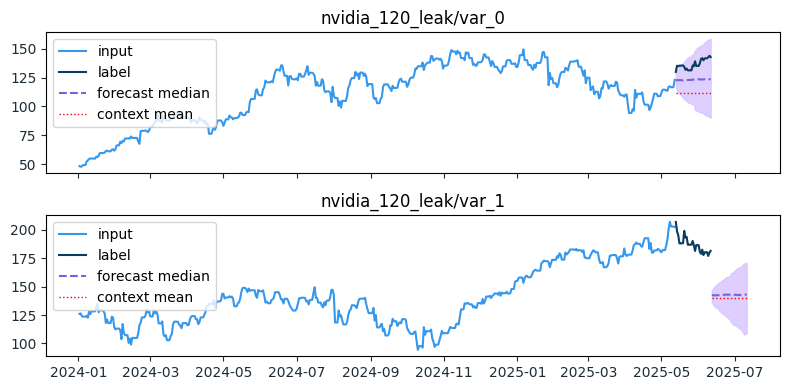

INFO:ts_toolkit.pipeline.eval:Input: 2021-12-26T00:00:00.000000, label: 2021-12-26T00:00:00.000000, prediction length: 8
2it [00:00, 256.13it/s]
INFO:ts_toolkit.pipeline.eval:Results for covid have been written to /home/nafiseh/GitHub/timeseries-research/tmp_results/Chronos2-Real_20260212-143058/Chronos2-Real/all_results.csv
INFO:ts_toolkit.pipeline.eval:Config has been written to /home/nafiseh/GitHub/timeseries-research/tmp_results/Chronos2-Real_20260212-143058/Chronos2-Real/Chronos2-Real_20260212-143058_config.yaml
/home/nafiseh/GitHub/timeseries-research/src/ts_toolkit/pipeline/visualization.py:145: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper left")


Var 0: start: 2021-09-06/2021-09-12
Var 1: start: 2021-09-06/2021-09-12


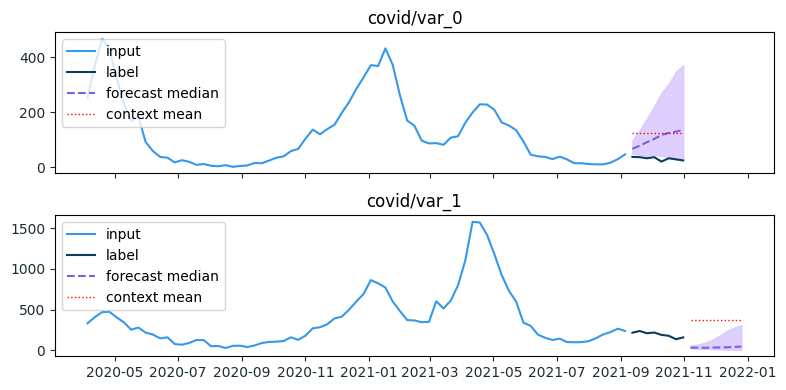

INFO:ts_toolkit.pipeline.runner:
--- ✅ All evaluations complete. ---


,dataset,variate,num_variates,model,eval_metrics/MeanAttractionRatio[0.5][512],eval_metrics/MeanBiasRatio[0.5][512],eval_metrics/PathVolatilityRatio[0.5][512],eval_metrics/PersistenceSkillRatio[0.5],eval_metrics/MeanSkillRatio[0.5][512],eval_metrics/NormalizedMeanBias[0.5],...,eval_metrics/MSE[0.5],eval_metrics/MAE[0.5],eval_metrics/MASE[0.5],eval_metrics/MAPE[0.5],eval_metrics/sMAPE[0.5],eval_metrics/MSIS,eval_metrics/RMSE[mean],eval_metrics/NRMSE[mean],eval_metrics/ND[0.5],eval_metrics/mean_weighted_sum_quantile_loss
0,nvidia_120_leak/short,MULTI,2,Chronos2-Real,1.582928,0.9500,10.842896,0.994677,0.369368,0.079986,...,172.254922,11.591298,5.742375,0.079639,0.083868,27.143609,13.124592,0.090839,0.080226,0.056772
0,covid/short,MULTI,2,Chronos2-Real,1.556619,0.5625,1.373146,2.344003,0.539030,-0.785991,...,3313.875082,43.803555,1.653352,1.413777,0.663586,10.121586,57.566267,1.464325,1.114240,0.891032


In [1]:
import pandas as pd
from ts_toolkit.pipeline.runner import TsPipeline
from ts_toolkit.pipeline.utils import load_config
import logging
logging.basicConfig(level=logging.INFO)

model_repertoire = {
    "Chronos2": {"name": "Chronos2", "params": { "batch_size": 64}},
    "Moirai": {"name": "Moirai", "params": {"repo_id": "Salesforce/moirai-1.1-R-large", "batch_size": 64}},
    "Toto": {"name": "Toto", "params": {"context_length": 4_096, "batch_size": 64}},
    # "Sundial": {"name": "Sundial", "params": { "batch_size": 64}},
}


all_results = pd.DataFrame()

for model_name in model_repertoire.keys():
    # config_path = "./configes/experiments/real.yaml"
    config_dict = {
            "experiment_name": f"{model_name}-Real",

            "paths": {
                "storage_path": "data/real",
                "output_path": "tmp_results"
            },
            "forecaster": {
                "name": "MedianEnsemble",
                "max_length": 512,
                "models": [model_repertoire[model_name]],
                "alias": f"{model_name}-Real"
            },
            "evaluation": {
                "to_univariate": False,
                "show_plot": True,
                "eval_substr": "dim0"
            },
            "datasets": [
                {"name": "nvidia_120_leak", "term": "short"},
                {"name": "covid", "term": "short"}
            ]
    }
    config = load_config(config_dict=config_dict)

    # --- Set up the evaluation pipeline ---
    pipeline = TsPipeline(config)
    print(pipeline.get_forecast_horizons())
    pipeline.run(skip_existing=False, num_plots=1)
    all_results = pd.concat([all_results, pipeline.get_results()])
    break

all_results

In [ ]:
all_results.round(2).sort_values("dataset", ascending=True)

,dataset,variate,num_variates,model,eval_metrics/MeanAttractionRatio[0.5][512],eval_metrics/MeanBiasRatio[0.5][512],eval_metrics/PathVolatilityRatio[0.5][512],eval_metrics/PersistenceSkillRatio[0.5],eval_metrics/MeanSkillRatio[0.5][512],eval_metrics/NormalizedMeanBias[0.5],...,eval_metrics/MSE[0.5],eval_metrics/MAE[0.5],eval_metrics/MASE[0.5],eval_metrics/MAPE[0.5],eval_metrics/sMAPE[0.5],eval_metrics/MSIS,eval_metrics/RMSE[mean],eval_metrics/NRMSE[mean],eval_metrics/ND[0.5],eval_metrics/mean_weighted_sum_quantile_loss
0,covid/short,MULTI,2,Chronos2-Real,1.56,0.56,1.37,2.34,0.54,-0.79,...,3313.88,43.80,1.65,1.41,0.66,10.12,57.57,1.46,1.11,0.89
0,covid/short,MULTI,2,Moirai-Real,1.18,0.56,2.01,1.51,0.35,-0.31,...,1074.61,28.28,1.08,0.85,0.58,9.69,32.78,0.83,0.72,0.53
0,covid/short,MULTI,2,Toto-Real,1.25,0.50,1.52,1.94,0.45,-0.41,...,1798.15,36.22,1.38,1.09,0.69,8.36,42.40,1.08,0.92,0.69
0,nvidia_120_leak/short,MULTI,2,Chronos2-Real,1.58,0.95,10.84,0.99,0.37,0.08,...,172.25,11.59,5.74,0.08,0.08,27.14,13.12,0.09,0.08,0.06
0,nvidia_120_leak/short,MULTI,2,Moirai-Real,2.23,0.98,0.86,1.48,0.55,0.12,...,385.11,17.30,8.58,0.12,0.13,30.63,19.62,0.14,0.12,0.09
0,nvidia_120_leak/short,MULTI,2,Toto-Real,1.69,0.95,1.14,1.10,0.41,0.09,...,216.40,12.84,6.36,0.09,0.09,28.48,14.71,0.10,0.09,0.07
